# 04 — Ensemble: Catboost + ElasticNet Blending

**职责**: 用最优树模型（catboost）和最优线性模型（elasticnet）做简单加权 Blending，在验证集上搜索最优权重 α，与单模型对比。

**流程**: 加载数据 → 80/20 切分 → 加载/训练模型 → 搜索最优 α → 对比 → 保存记录

**输入**: `outputs/models/<run_id>/catboost.pkl`, `outputs/models/<run_id>/selected_features.json`, `data/raw/train_data.csv`  
**输出**: `outputs/ensemble_history.csv`, `outputs/figures/ensemble_blending_*.png`

In [4]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import json
import joblib
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score

from config import DATA_RAW, TARGET, MODEL_DIR, FIG_DIR, RANDOM_STATE
from src.feature_engineering import GroupPCATransformer, build_feature_matrix_for_pca
from src.preprocessing import load_and_clean
from src.models import discover_models

RUN_HISTORY_PATH = MODEL_DIR.parent / 'run_history.csv'
ENSEMBLE_HISTORY_PATH = MODEL_DIR.parent / 'ensemble_history.csv'

RUN_ID = '20260404_021054'
ENSEMBLE_NOTES = ''

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


## 1. 加载数据 + 80/20 切分 + 特征变换

使用与 `03_modeling` 相同的 80/20 时序切分，在训练集上 fit `GroupPCATransformer`，transform 训练集和验证集。

In [5]:
run_dir = MODEL_DIR / RUN_ID

with open(run_dir / 'selected_features.json') as f:
    selected_features = json.load(f)
print(f'Run: {RUN_ID}, selected_features: {len(selected_features)} 个')

df = load_and_clean(DATA_RAW)
df = df.sort_values('startdate').reset_index(drop=True)
X_raw, y_all, _ = build_feature_matrix_for_pca(df, TARGET)

split_idx = int(len(X_raw) * 0.8)
X_raw_train, X_raw_val = X_raw.iloc[:split_idx], X_raw.iloc[split_idx:]
y_train, y_test = y_all.iloc[:split_idx], y_all.iloc[split_idx:]

gpca = GroupPCATransformer(random_state=RANDOM_STATE, var_threshold=0.95)
gpca.fit(X_raw_train)
X_train = gpca.transform(X_raw_train)[selected_features]
X_val = gpca.transform(X_raw_val)[selected_features]

print(f'训练集: {X_train.shape}, 验证集: {X_val.shape}')

Run: 20260404_021054, selected_features: 92 个
训练集: (300587, 92), 验证集: (75147, 92)


## 2. 加载 catboost（.pkl）+ 训练 elasticnet（秒级）

catboost 直接加载 `03_modeling` 保存的 `.pkl`（已在 80% 数据上训练），elasticnet 现场快速训练并保存 `.pkl`。

In [11]:
# catboost: 加载已有 .pkl
cat_pipe = joblib.load(run_dir / 'catboost.pkl')
cat_pred = cat_pipe.predict(X_val)
cat_rmse = float(np.sqrt(mean_squared_error(y_test, cat_pred)))
cat_r2 = float(r2_score(y_test, cat_pred))
print(f'catboost   (加载 .pkl) 验证 RMSE={cat_rmse:.4f}, R²={cat_r2:.4f}')

# elasticnet: 有 .pkl 则加载，否则现场训练并保存
enet_pkl_path = run_dir / 'elasticnet.pkl'
if enet_pkl_path.exists():
    enet_pipe = joblib.load(enet_pkl_path)
    print(f'elasticnet (加载 .pkl)')
else:
    registry = discover_models()
    enet_pipe = registry['elasticnet'].build_pipeline()
    enet_pipe.fit(X_train, y_train)
    joblib.dump(enet_pipe, enet_pkl_path)
    print(f'elasticnet (现场训练，已保存 → {enet_pkl_path})')

enet_pred = enet_pipe.predict(X_val)
enet_rmse = float(np.sqrt(mean_squared_error(y_test, enet_pred)))
enet_r2 = float(r2_score(y_test, enet_pred))
print(f'elasticnet 验证 RMSE={enet_rmse:.4f}, R²={enet_r2:.4f}')

predictions = {'catboost': cat_pred, 'elasticnet': enet_pred}
base_results = pd.DataFrame([
    {'Model': 'catboost',   'RMSE': cat_rmse,  'R²': cat_r2},
    {'Model': 'elasticnet', 'RMSE': enet_rmse, 'R²': enet_r2},
]).set_index('Model')
base_results

/Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


catboost   (加载 .pkl) 验证 RMSE=1.0959, R²=0.9703
elasticnet (现场训练) 验证 RMSE=1.5153, R²=0.9432
elasticnet 已保存 → /Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/outputs/models/20260404_021054/elasticnet.pkl


,RMSE,R²
Model,,
catboost,1.095950,0.970272
elasticnet,1.515323,0.943167


## 3. 搜索最优 Blending 权重 α

`pred = α · catboost + (1-α) · elasticnet`，在验证集上遍历 α ∈ [0, 1]，找到 RMSE 最低的权重。

最优 α = 0.78
Blending  RMSE = 1.0540, R² = 0.9725
Catboost  RMSE = 1.0959, R² = 0.9703
相对 catboost 改进: +3.82%

→ Blending 优于 catboost 单模型


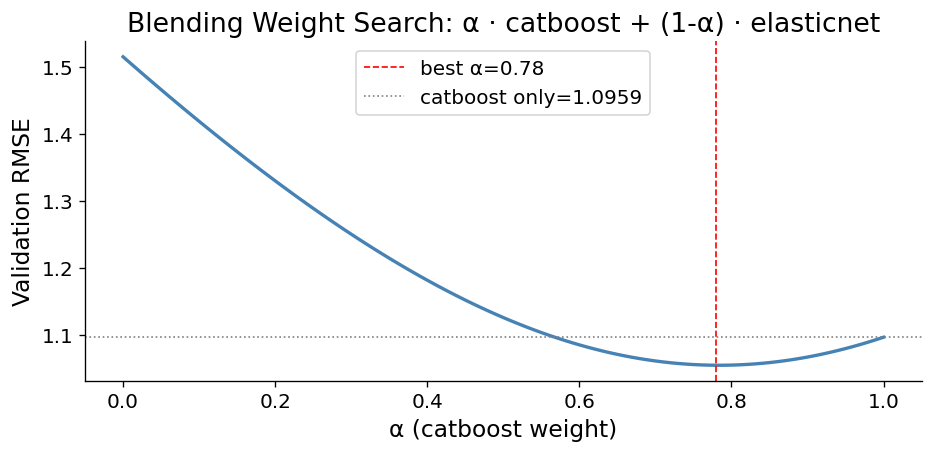

,Model,Type,RMSE,R²
0,Blending,Ensemble,1.054031,0.972502
1,catboost,Base,1.095950,0.970272
2,elasticnet,Base,1.515323,0.943167


In [7]:
alphas = np.arange(0.0, 1.01, 0.01)
rmses = []
for a in alphas:
    blend = a * cat_pred + (1 - a) * enet_pred
    rmses.append(float(np.sqrt(mean_squared_error(y_test, blend))))

best_idx = int(np.argmin(rmses))
best_alpha = alphas[best_idx]
ensemble_rmse = rmses[best_idx]
ensemble_r2 = float(r2_score(y_test, best_alpha * cat_pred + (1 - best_alpha) * enet_pred))
ensemble_bias = float(np.mean(y_test.values - (best_alpha * cat_pred + (1 - best_alpha) * enet_pred)))
stack_pred = best_alpha * cat_pred + (1 - best_alpha) * enet_pred

print(f'最优 α = {best_alpha:.2f}')
print(f'Blending  RMSE = {ensemble_rmse:.4f}, R² = {ensemble_r2:.4f}')
print(f'Catboost  RMSE = {cat_rmse:.4f}, R² = {cat_r2:.4f}')
improvement = (cat_rmse - ensemble_rmse) / cat_rmse * 100
print(f'相对 catboost 改进: {improvement:+.2f}%')

if improvement > 0:
    print('\n→ Blending 优于 catboost 单模型')
else:
    print('\n→ Catboost 单模型更优（或持平），blending 无额外收益')

# α-RMSE 曲线
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(alphas, rmses, lw=2, color='steelblue')
ax.axvline(best_alpha, ls='--', color='red', lw=1, label=f'best α={best_alpha:.2f}')
ax.axhline(cat_rmse, ls=':', color='gray', lw=1, label=f'catboost only={cat_rmse:.4f}')
ax.set_xlabel('α (catboost weight)')
ax.set_ylabel('Validation RMSE')
ax.set_title('Blending Weight Search: α · catboost + (1-α) · elasticnet')
ax.legend()
plt.tight_layout()
plt.show()

comparison_df = pd.DataFrame([
    {'Model': 'catboost',   'Type': 'Base',     'RMSE': cat_rmse,      'R²': cat_r2},
    {'Model': 'elasticnet', 'Type': 'Base',     'RMSE': enet_rmse,     'R²': enet_r2},
    {'Model': 'Blending',   'Type': 'Ensemble', 'RMSE': ensemble_rmse, 'R²': ensemble_r2},
]).sort_values('RMSE').reset_index(drop=True)
comparison_df


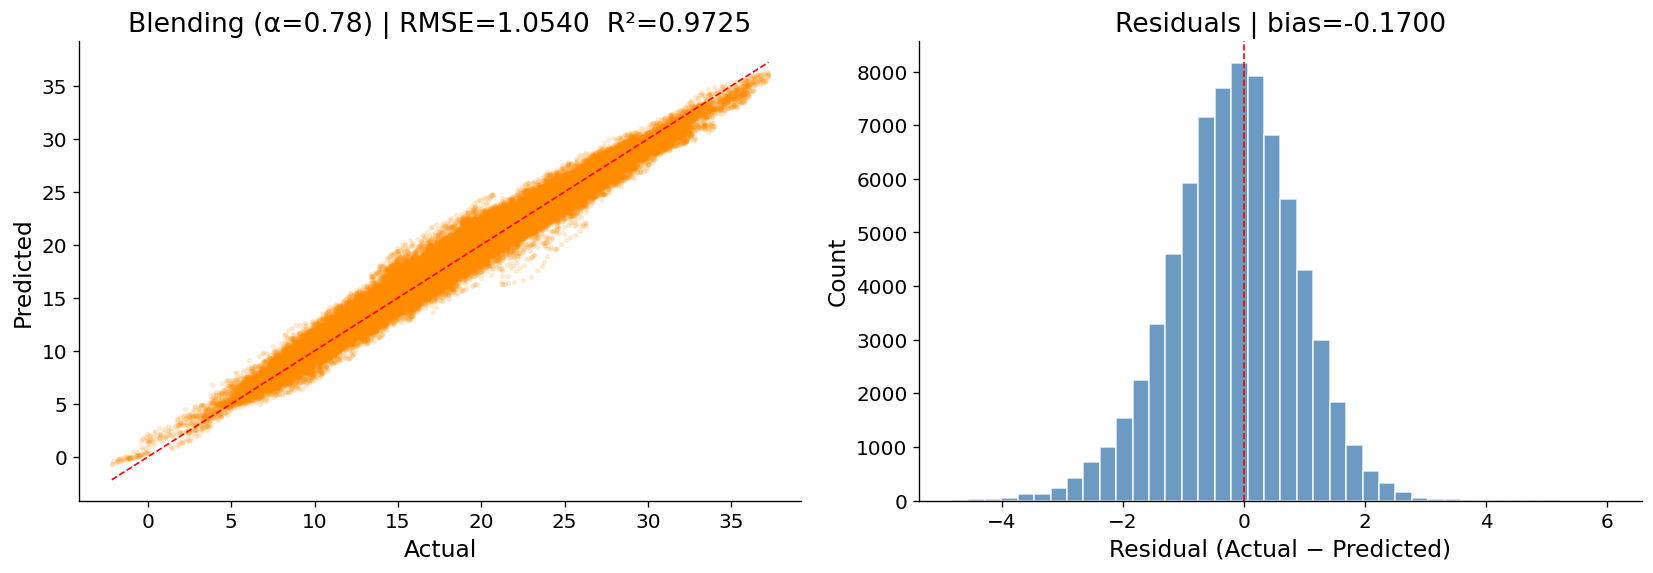

Saved figure -> /Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/outputs/figures/ensemble_blending_20260407_201942.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(y_test, stack_pred, s=5, alpha=0.12, color='darkorange')
lims = [float(min(y_test.min(), stack_pred.min())), float(max(y_test.max(), stack_pred.max()))]
ax.plot(lims, lims, 'r--', lw=1)
ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')
ax.set_title(f'Blending (α={best_alpha:.2f}) | RMSE={ensemble_rmse:.4f}  R²={ensemble_r2:.4f}')

residuals = y_test.values - stack_pred
ax = axes[1]
ax.hist(residuals, bins=40, edgecolor='white', color='steelblue', alpha=0.8)
ax.axvline(0, ls='--', color='red', lw=1)
ax.set_xlabel('Residual (Actual − Predicted)')
ax.set_ylabel('Count')
ax.set_title(f'Residuals | bias={ensemble_bias:.4f}')

FIG_DIR.mkdir(parents=True, exist_ok=True)
ensemble_run_id = datetime.now().strftime('%Y%m%d_%H%M%S')
fig_name = f'ensemble_blending_{ensemble_run_id}.png'
fig_path = FIG_DIR / fig_name
plt.tight_layout()
plt.savefig(fig_path, bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved figure -> {fig_path}')

## 4. 保存 ensemble 结果

将本次 Blending 的配置和指标追加到 `outputs/ensemble_history.csv`。

In [10]:
stack_names = ['catboost', 'elasticnet']
meta_coef_vec = [best_alpha, 1 - best_alpha]

record = {
    "ensemble_run_id": ensemble_run_id,
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "select_by": "test_rmse",
    "stack_top_k": 2,
    "stacking_members": json.dumps(stack_names),
    "stacking_member_run_ids": json.dumps([RUN_ID, RUN_ID]),
    "stacking_member_rmse": json.dumps([round(cat_rmse, 4), round(enet_rmse, 4)]),
    "stacking_blend_method": "weighted_average",
    "stacking_oof_rmse": np.nan,
    "stacking_meta_coefs": json.dumps([round(float(c), 4) for c in meta_coef_vec]),
    "stacking_rmse": round(ensemble_rmse, 4),
    "stacking_r2": round(ensemble_r2, 4),
    "stacking_intercept": 0.0,
    "stacking_bias": round(ensemble_bias, 4),
    "figure_path": f"outputs/figures/{fig_name}",
    "notes": ENSEMBLE_NOTES,
}

new_row = pd.DataFrame([record])
if ENSEMBLE_HISTORY_PATH.exists():
    ensemble_history = pd.concat([pd.read_csv(ENSEMBLE_HISTORY_PATH), new_row], ignore_index=True)
else:
    ensemble_history = new_row
ensemble_history.to_csv(ENSEMBLE_HISTORY_PATH, index=False)

print(f"Saved ensemble history -> {ENSEMBLE_HISTORY_PATH}")

improvement = (cat_rmse - ensemble_rmse) / cat_rmse * 100
print(f"\nBlending 小结")
print("=" * 34)
print(f"catboost 单模型 RMSE:   {cat_rmse:.4f}")
print(f"elasticnet 单模型 RMSE: {enet_rmse:.4f}")
print(f"Blending RMSE:          {ensemble_rmse:.4f}")
print(f"最优权重: α={best_alpha:.2f} (catboost), {1-best_alpha:.2f} (elasticnet)")
print(f"相对 catboost: {improvement:+.2f}%")
if improvement > 0:
    print("\nBlending 优于最优单模型，建议采用。")
else:
    print("\nBlending 未优于最优单模型，建议直接使用 catboost。")


Saved ensemble history -> /Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/outputs/ensemble_history.csv

Blending 小结
catboost 单模型 RMSE:   1.0959
elasticnet 单模型 RMSE: 1.5153
Blending RMSE:          1.0540
最优权重: α=0.78 (catboost), 0.22 (elasticnet)
相对 catboost: +3.82%

Blending 优于最优单模型，建议采用。
